# EDA — UCI Credit Card Default

**Dataset** : 30 000 clients de cartes de crédit taïwanais observés sur 6 mois
(avril → septembre 2005).
**Cible** : `default` (1 = défaut de paiement le mois suivant, 0 sinon).

Ce notebook couvre 10 sections :
1. Vue structurelle
2. Qualité des données
3. Statistiques descriptives
4. Analyse de la cible
5. Univariate analysis
6. Bivariate analysis (variable vs cible)
7. Multivariate (corrélations, heatmaps)
8. Outliers
9. Analyses temporelles (6 mois)
10. Feature engineering & dataset processed

Les cleaning rules et le feature engineering sont définis dans
`src/scoring/data.py` afin de garantir la cohérence entre EDA, training et API.

## ⚙️ Setup

In [1]:
import sys
from pathlib import Path

# Make src importable
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

FIG_DIR = ROOT / 'docs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

from scoring.data import (
    load_raw, clean, decode_categoricals, engineer_features, prepare,
    PAY_COLS, BILL_COLS, PAY_AMT_COLS, TARGET,
)

df_raw = load_raw()
df = clean(df_raw)
print(f'Raw   : {df_raw.shape}')
print(f'Clean : {df.shape}')
df.head()

Raw   : (30000, 25)
Clean : (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 1️⃣ Vue structurelle

**Objectif** : comprendre la forme et le contenu brut du dataset avant
toute analyse.

In [2]:
print('Shape :', df.shape)
print('Memory:', df.memory_usage(deep=True).sum() / 1024**2, 'MB')

Shape : (30000, 24)
Memory: 5.493289947509766 MB


In [3]:
df.dtypes.value_counts()

float64    13
int64      11
Name: count, dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LIMIT_BAL  30000 non-null  float64
 1   SEX        30000 non-null  int64  
 2   EDUCATION  30000 non-null  int64  
 3   MARRIAGE   30000 non-null  int64  
 4   AGE        30000 non-null  int64  
 5   PAY_0      30000 non-null  int64  
 6   PAY_2      30000 non-null  int64  
 7   PAY_3      30000 non-null  int64  
 8   PAY_4      30000 non-null  int64  
 9   PAY_5      30000 non-null  int64  
 10  PAY_6      30000 non-null  int64  
 11  BILL_AMT1  30000 non-null  float64
 12  BILL_AMT2  30000 non-null  float64
 13  BILL_AMT3  30000 non-null  float64
 14  BILL_AMT4  30000 non-null  float64
 15  BILL_AMT5  30000 non-null  float64
 16  BILL_AMT6  30000 non-null  float64
 17  PAY_AMT1   30000 non-null  float64
 18  PAY_AMT2   30000 non-null  float64
 19  PAY_AMT3   30000 non-null  float64
 20  PAY_AM

In [5]:
df.nunique().sort_values()

default          2
SEX              2
MARRIAGE         3
EDUCATION        4
PAY_5           10
PAY_6           10
PAY_0           11
PAY_2           11
PAY_3           11
PAY_4           11
AGE             56
LIMIT_BAL       81
PAY_AMT5      6897
PAY_AMT4      6937
PAY_AMT6      6939
PAY_AMT3      7518
PAY_AMT2      7899
PAY_AMT1      7943
BILL_AMT6    20604
BILL_AMT5    21010
BILL_AMT4    21548
BILL_AMT3    22026
BILL_AMT2    22346
BILL_AMT1    22723
dtype: int64

In [6]:
print('Doublons :', df.duplicated().sum())

Doublons : 35


In [7]:
# Vue rapide : 3 lignes aléatoires
df.sample(3, random_state=0)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
8225,20000.0,1,1,2,33,1,2,2,2,2,2,17971.0,17399.0,19057.0,18453.0,19755.0,19288.0,0.0,2260.0,0.0,1600.0,0.0,644.0,0
10794,20000.0,2,2,2,35,0,0,2,0,0,0,16528.0,19347.0,18600.0,19000.0,19000.0,20000.0,3400.0,0.0,1000.0,0.0,1000.0,0.0,0
9163,230000.0,2,1,1,44,1,-1,-1,-1,-1,-2,3884.0,949.0,2864.0,933.0,0.0,0.0,949.0,2873.0,933.0,0.0,0.0,0.0,0


## 2️⃣ Qualité des données

**Objectif** : repérer valeurs manquantes, codes anormaux, valeurs
incohérentes. Le dataset UCI a quelques codes non documentés sur
`EDUCATION` (0, 5, 6) et `MARRIAGE` (0) — la fonction `clean()` les
remappe vers la modalité "others".

In [8]:
missing = df.isnull().sum()
print('Total missing values :', missing.sum())
missing[missing > 0]

Total missing values : 0


Series([], dtype: int64)

In [9]:
# Codes catégoriels après cleaning
print('EDUCATION :', sorted(df['EDUCATION'].unique()))
print('MARRIAGE  :', sorted(df['MARRIAGE'].unique()))
print('SEX       :', sorted(df['SEX'].unique()))

EDUCATION : [1, 2, 3, 4]
MARRIAGE  : [1, 2, 3]
SEX       : [1, 2]


In [10]:
# Avant/après cleaning sur EDUCATION
print('Avant cleaning :')
print(df_raw['EDUCATION'].value_counts().sort_index())
print()
print('Après cleaning :')
print(df['EDUCATION'].value_counts().sort_index())

Avant cleaning :
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

Après cleaning :
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64


In [11]:
# Codes PAY (status historique)
for col in PAY_COLS:
    print(f'{col} : {sorted(df[col].unique())}')

PAY_0 : [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
PAY_2 : [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
PAY_3 : [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
PAY_4 : [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
PAY_5 : [-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]
PAY_6 : [-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]


In [12]:
# Valeurs négatives sur BILL_AMT (peut signaler un avoir/remboursement)
neg_bill = (df[BILL_COLS] < 0).sum()
print('Lignes avec BILL_AMT négatif (par mois) :')
print(neg_bill)
print()
print(f'% de clients avec au moins un BILL négatif : '
      f'{((df[BILL_COLS] < 0).any(axis=1).mean() * 100):.1f}%')

Lignes avec BILL_AMT négatif (par mois) :
BILL_AMT1    590
BILL_AMT2    669
BILL_AMT3    655
BILL_AMT4    675
BILL_AMT5    655
BILL_AMT6    688
dtype: int64

% de clients avec au moins un BILL négatif : 6.4%


## 3️⃣ Statistiques descriptives

**Objectif** : valeurs typiques, dispersion, asymétrie, queues lourdes.

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.842267,0.744494,1.0,1.00,2.0,2.00,4.0
MARRIAGE,30000.0,1.557267,0.521405,1.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


In [14]:
# Quantiles étendus pour repérer les queues extrêmes
df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,10000.00,20000.0,50000.00,140000.0,240000.00,430000.00,500000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,1.0,1.00,2.0,2.00,2.00,2.00,2.0
EDUCATION,30000.0,1.842267,0.744494,1.0,1.00,1.0,1.00,2.0,2.00,3.00,4.00,4.0
MARRIAGE,30000.0,1.557267,0.521405,1.0,1.00,1.0,1.00,2.0,2.00,2.00,3.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,22.00,23.0,28.00,34.0,41.00,53.00,60.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-2.00,-2.0,-1.00,0.0,0.00,2.00,3.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-2.00,-2.0,-1.00,0.0,0.00,2.00,3.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-2.00,-2.0,-1.00,0.0,0.00,2.00,3.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-2.00,-2.0,-1.00,0.0,0.00,2.00,3.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-2.00,-2.0,-1.00,0.0,0.00,2.00,3.00,8.0


In [15]:
# Skewness (asymétrie) — |skew| > 1 indique une distribution très asymétrique
skew = df.drop(columns=[TARGET]).skew().sort_values(ascending=False)
print('Top 10 variables les plus asymétriques :')
print(skew.head(10))

Top 10 variables les plus asymétriques :
PAY_AMT2     30.453817
PAY_AMT3     17.216635
PAY_AMT1     14.668364
PAY_AMT4     12.904985
PAY_AMT5     11.127417
PAY_AMT6     10.640727
BILL_AMT3     3.087830
BILL_AMT5     2.876380
BILL_AMT6     2.846645
BILL_AMT4     2.821965
dtype: float64


In [16]:
# Statistiques séparées par classe de la cible
df.groupby(TARGET).describe().T

default                      0              1
LIMIT_BAL count   23364.000000    6636.000000
          mean   178099.726074  130109.656420
          std    131628.359660  115378.540571
          min     10000.000000   10000.000000
          25%     70000.000000   50000.000000
...                        ...            ...
PAY_AMT6  min         0.000000       0.000000
          25%       300.000000       0.000000
          50%      1706.000000    1000.000000
          75%      4545.000000    2974.500000
          max    528666.000000  345293.000000

[184 rows x 2 columns]

## 4️⃣ Analyse de la cible

**Constat** : ~22% de défauts → dataset **déséquilibré** → nécessite SMOTE
ou `class_weight='balanced'` lors du training.

In [17]:
target_counts = df[TARGET].value_counts()
target_pct = df[TARGET].value_counts(normalize=True) * 100

print(target_counts)
print()
print(target_pct.round(2).astype(str) + ' %')

default
0    23364
1     6636
Name: count, dtype: int64

default
0    77.88 %
1    22.12 %
Name: proportion, dtype: object


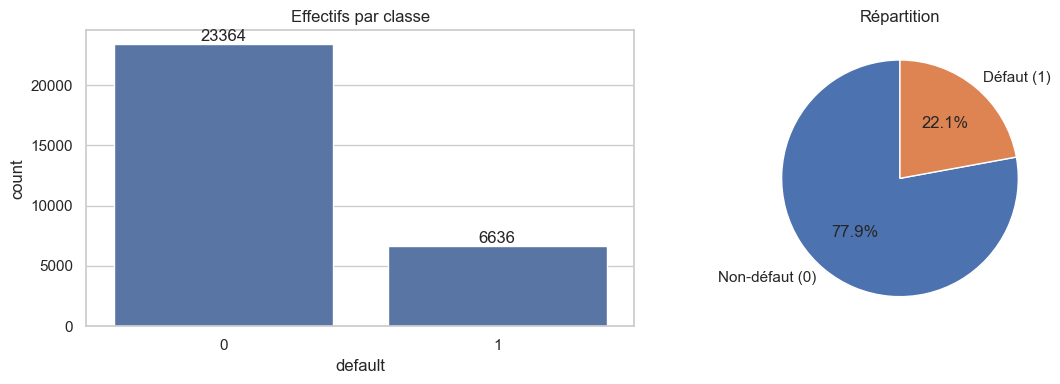

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
sns.countplot(x=TARGET, data=df, ax=axes[0])
axes[0].set_title('Effectifs par classe')
for p in axes[0].patches:
    axes[0].annotate(int(p.get_height()),
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom')

# Pie chart
axes[1].pie(target_counts, labels=['Non-défaut (0)', 'Défaut (1)'],
            autopct='%1.1f%%', startangle=90, colors=['#4C72B0', '#DD8452'])
axes[1].set_title('Répartition')

plt.tight_layout()
plt.savefig(FIG_DIR / '04_target_balance.png', dpi=120, bbox_inches='tight')
plt.show()

## 5️⃣ Analyse univariée

### 5.A — Variables numériques continues

Histogrammes + boxplots pour `LIMIT_BAL`, `AGE`, `BILL_AMT*`, `PAY_AMT*`.

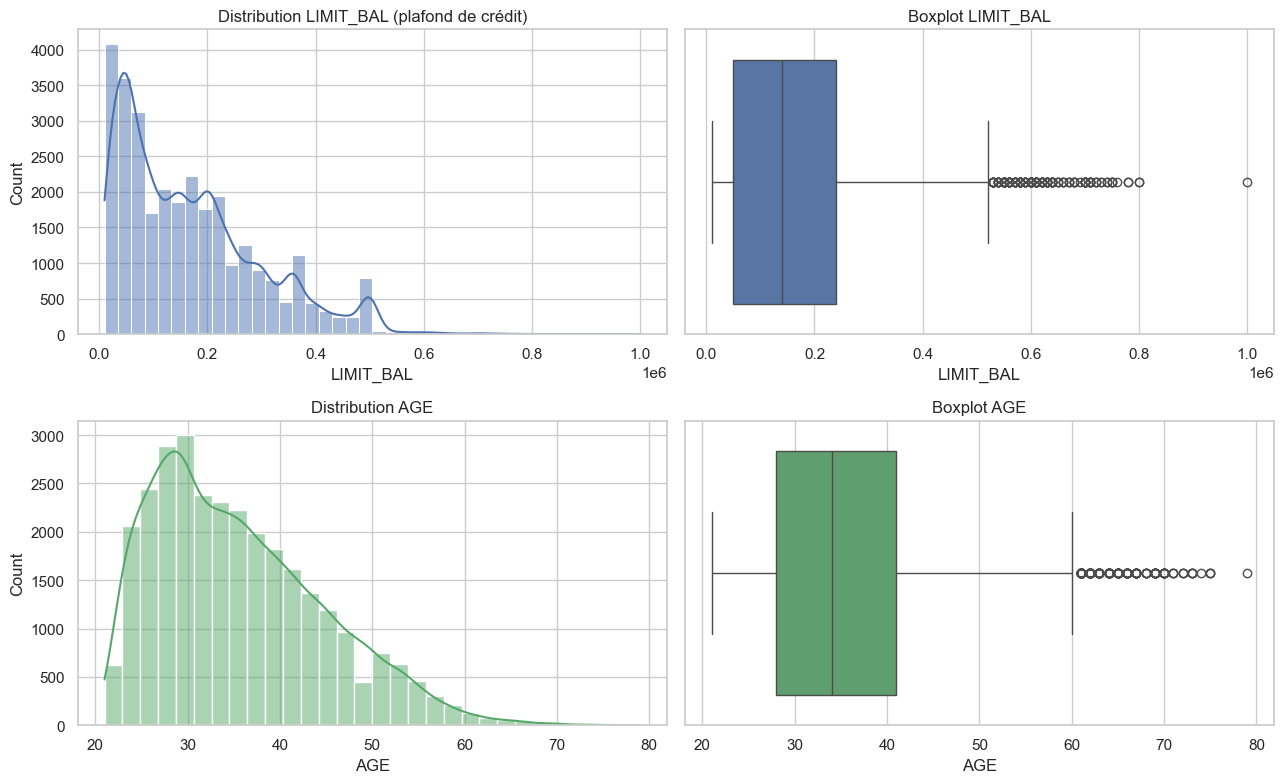

In [19]:
# LIMIT_BAL et AGE
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.histplot(df['LIMIT_BAL'], kde=True, ax=axes[0, 0], bins=40, color='#4C72B0')
axes[0, 0].set_title('Distribution LIMIT_BAL (plafond de crédit)')
sns.boxplot(x=df['LIMIT_BAL'], ax=axes[0, 1], color='#4C72B0')
axes[0, 1].set_title('Boxplot LIMIT_BAL')

sns.histplot(df['AGE'], kde=True, ax=axes[1, 0], bins=30, color='#55A868')
axes[1, 0].set_title('Distribution AGE')
sns.boxplot(x=df['AGE'], ax=axes[1, 1], color='#55A868')
axes[1, 1].set_title('Boxplot AGE')

plt.tight_layout()
plt.savefig(FIG_DIR / '05a_limit_age.png', dpi=120, bbox_inches='tight')
plt.show()

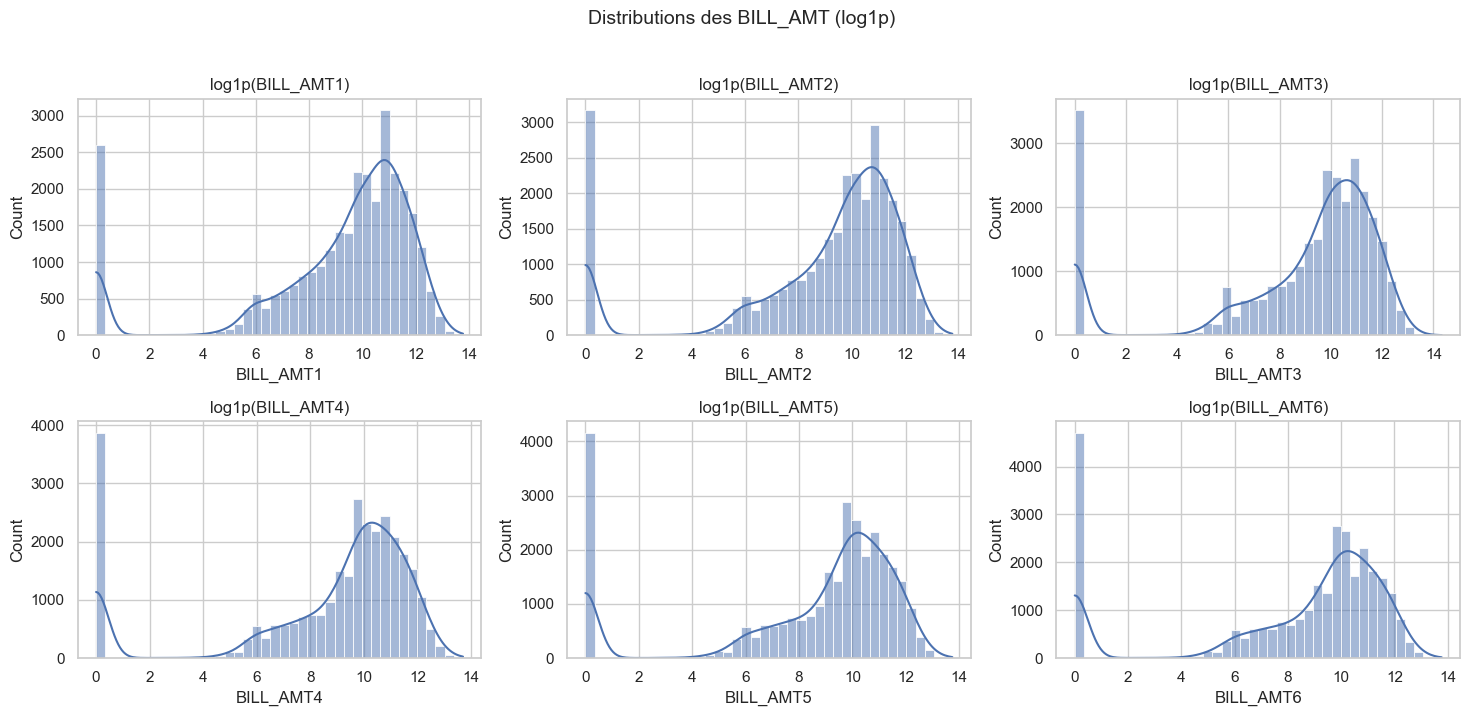

In [20]:
# BILL_AMT (en log car très skewé) — grille 2x3
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), BILL_COLS):
    sns.histplot(np.log1p(df[col].clip(lower=0)), kde=True, ax=ax, bins=40)
    ax.set_title(f'log1p({col})')
plt.suptitle('Distributions des BILL_AMT (log1p)', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / '05a_bill_amt_log.png', dpi=120, bbox_inches='tight')
plt.show()

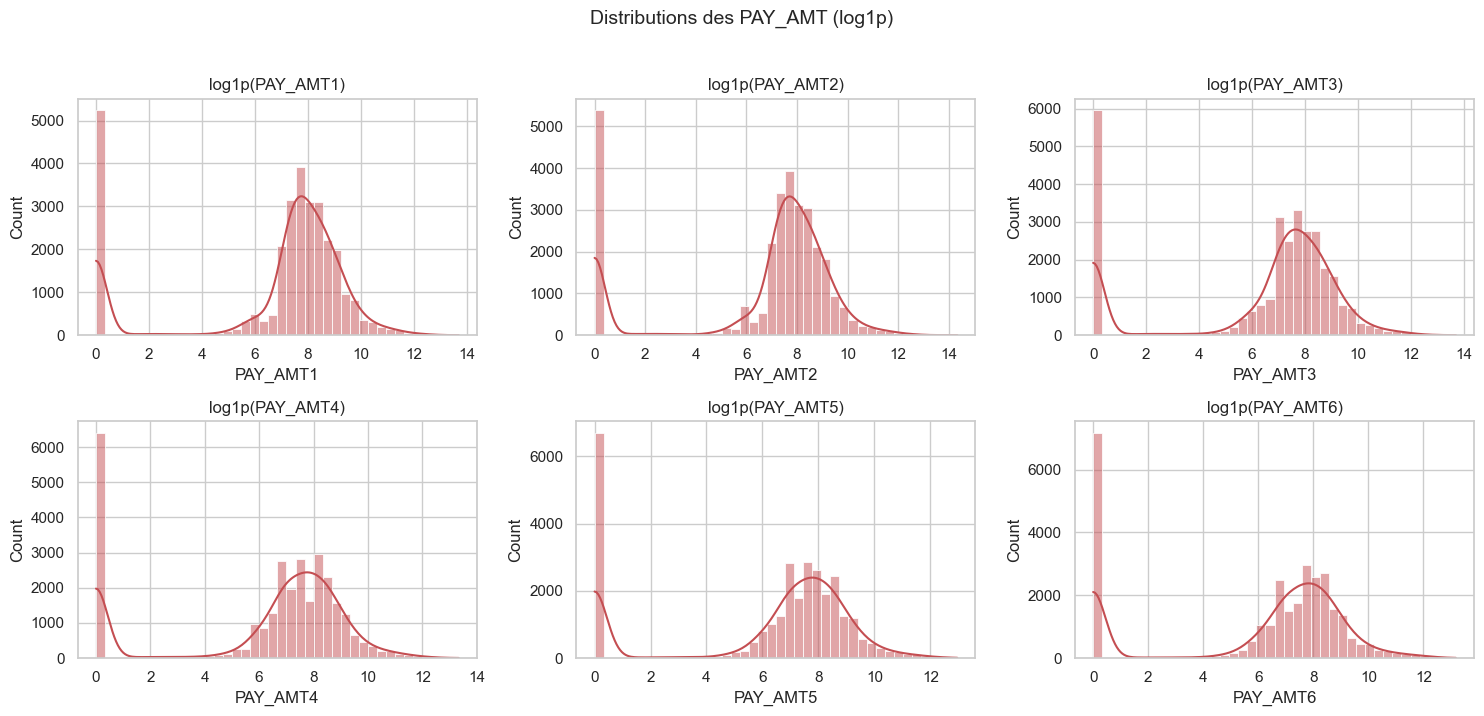

In [21]:
# PAY_AMT (idem)
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), PAY_AMT_COLS):
    sns.histplot(np.log1p(df[col].clip(lower=0)), kde=True, ax=ax, bins=40, color='#C44E52')
    ax.set_title(f'log1p({col})')
plt.suptitle('Distributions des PAY_AMT (log1p)', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / '05a_pay_amt_log.png', dpi=120, bbox_inches='tight')
plt.show()

### 5.B — Variables catégorielles

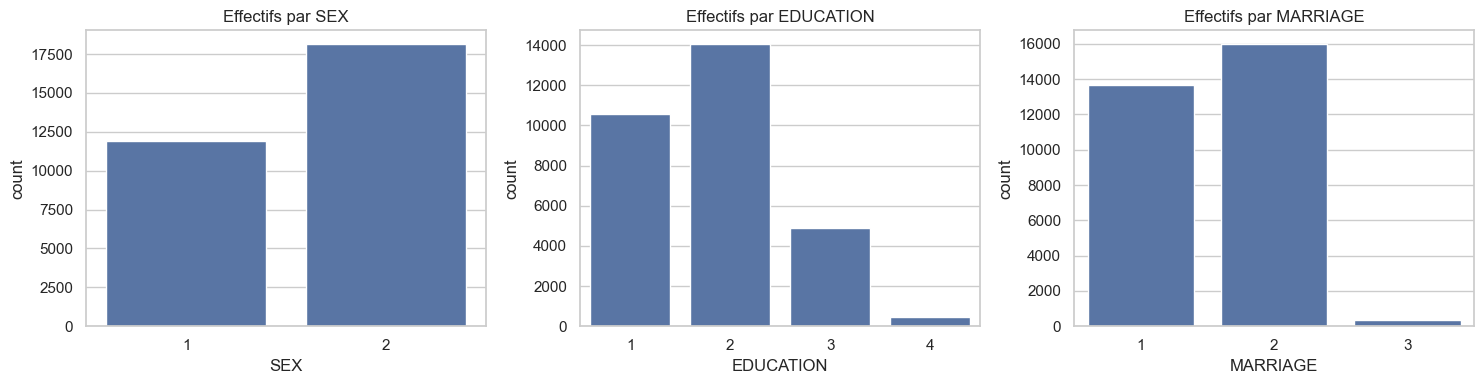

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['SEX', 'EDUCATION', 'MARRIAGE']):
    sns.countplot(x=col, data=df, ax=ax)
    ax.set_title(f'Effectifs par {col}')
plt.tight_layout()
plt.savefig(FIG_DIR / '05b_categoricals.png', dpi=120, bbox_inches='tight')
plt.show()

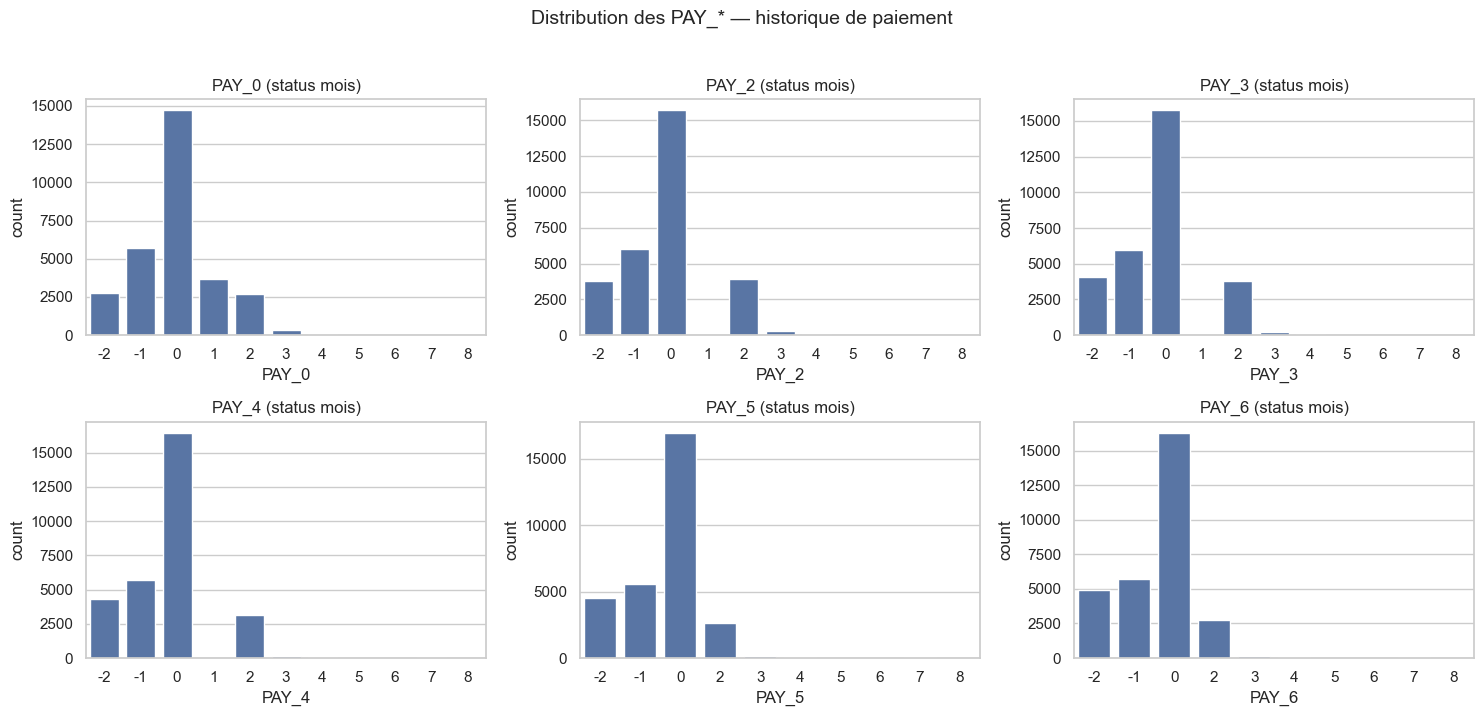

In [23]:
# Distribution des PAY_* (status historique paiement)
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), PAY_COLS):
    sns.countplot(x=col, data=df, ax=ax)
    ax.set_title(f'{col} (status mois)')
plt.suptitle('Distribution des PAY_* — historique de paiement', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / '05b_pay_status.png', dpi=120, bbox_inches='tight')
plt.show()

## 6️⃣ Analyse bivariée (variable vs cible)

**Objectif** : repérer quelles variables ont une **distribution
différente selon que le client a fait défaut ou non** — ce sont les
candidates fortes pour la prédiction.

### 6.A — Numérique vs cible (boxplots)

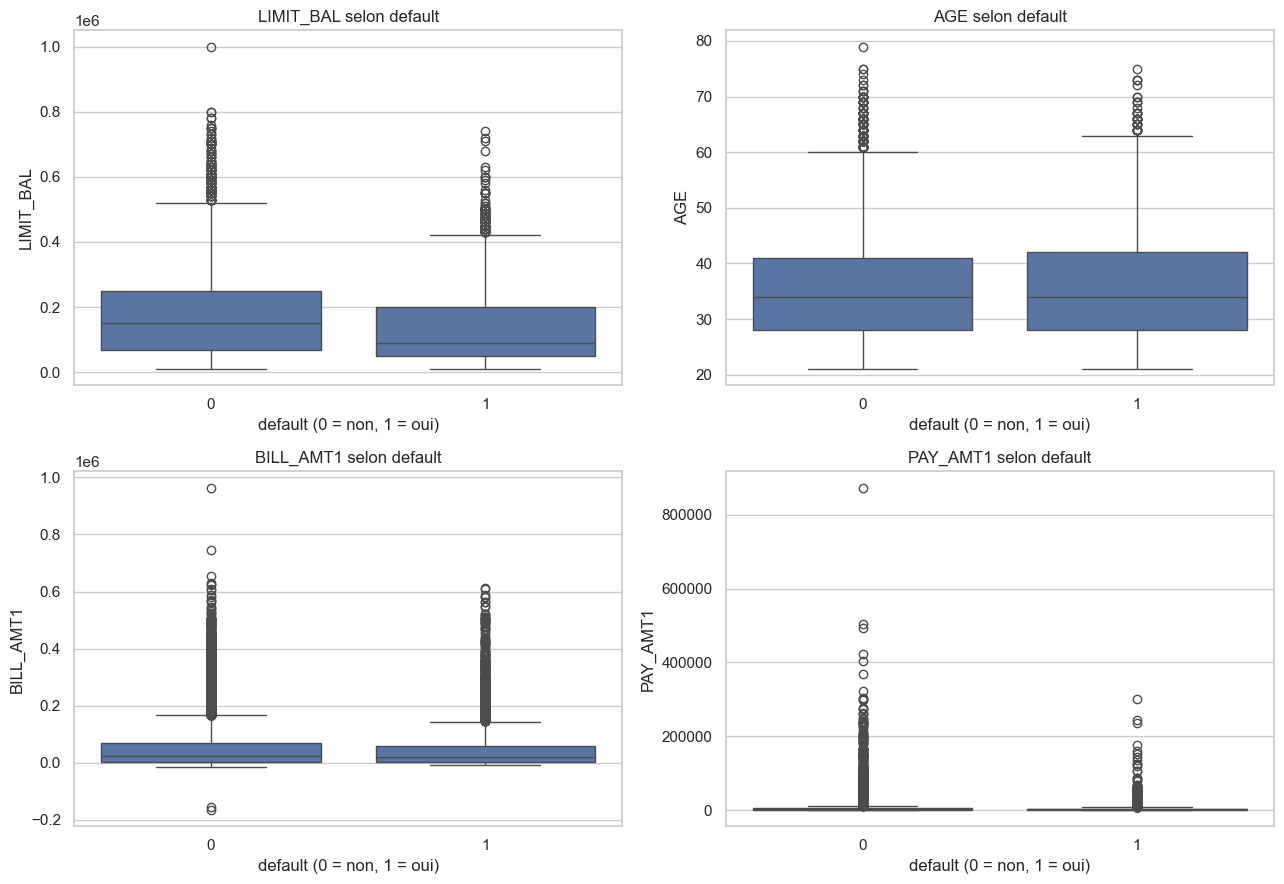

In [24]:
num_cols_compare = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), num_cols_compare):
    sns.boxplot(x=TARGET, y=col, data=df, ax=ax)
    ax.set_title(f'{col} selon {TARGET}')
    ax.set_xlabel('default (0 = non, 1 = oui)')
plt.tight_layout()
plt.savefig(FIG_DIR / '06a_boxplots_target.png', dpi=120, bbox_inches='tight')
plt.show()

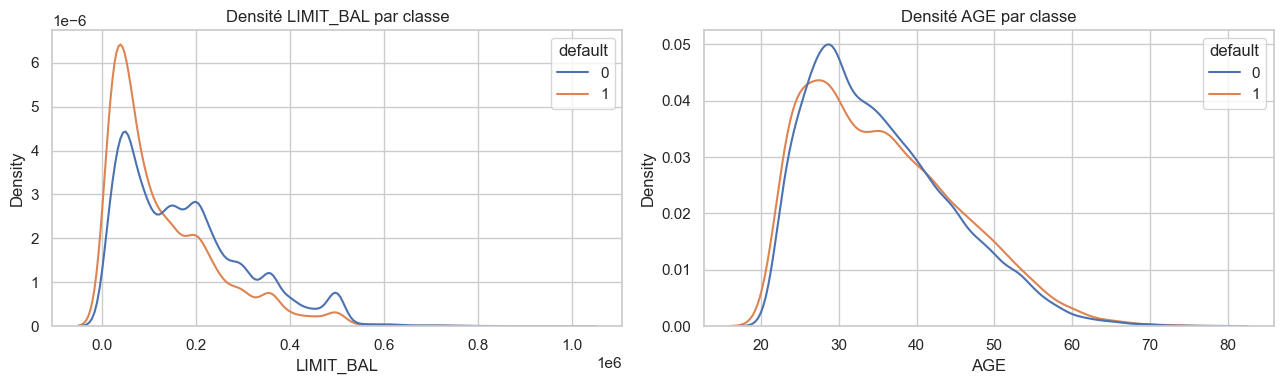

In [25]:
# Densités superposées (KDE) — voir le chevauchement des distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.kdeplot(data=df, x='LIMIT_BAL', hue=TARGET, common_norm=False, ax=axes[0])
axes[0].set_title('Densité LIMIT_BAL par classe')
sns.kdeplot(data=df, x='AGE', hue=TARGET, common_norm=False, ax=axes[1])
axes[1].set_title('Densité AGE par classe')
plt.tight_layout()
plt.savefig(FIG_DIR / '06a_kde_target.png', dpi=120, bbox_inches='tight')
plt.show()

In [26]:
# Test statistique Mann-Whitney (non-paramétrique) — variables numériques clés
from scipy.stats import mannwhitneyu
print('Test de Mann-Whitney U (H0: distributions identiques entre classes)')
print('-' * 75)
print(f'{"Variable":<15} {"U-stat":>15} {"p-value":>15} {"significatif":>15}')
print('-' * 75)
for col in ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1', 'PAY_0']:
    g0 = df.loc[df[TARGET] == 0, col]
    g1 = df.loc[df[TARGET] == 1, col]
    u, p = mannwhitneyu(g0, g1, alternative='two-sided')
    sig = 'OUI' if p < 0.001 else 'non'
    print(f'{col:<15} {u:>15.0f} {p:>15.2e} {sig:>15}')

Test de Mann-Whitney U (H0: distributions identiques entre classes)
---------------------------------------------------------------------------
Variable                 U-stat         p-value    significatif
---------------------------------------------------------------------------
LIMIT_BAL              95786286       1.23e-189             OUI
AGE                    76966880        3.73e-01             non
BILL_AMT1              80252446        1.15e-05             OUI
PAY_AMT1               94780733       4.62e-170             OUI
PAY_0                  48108422        0.00e+00             OUI


### 6.B — Catégorielle vs cible (taux de défaut)

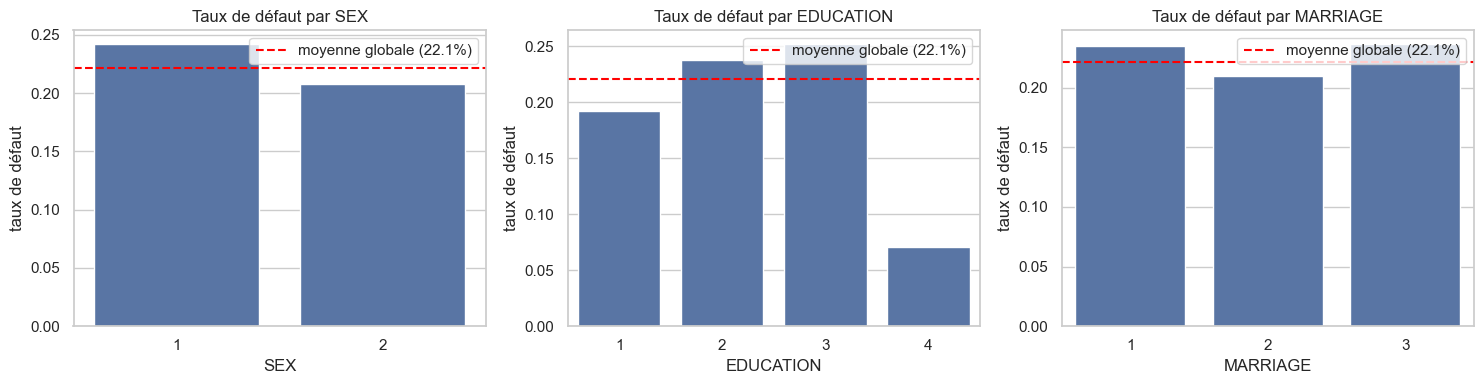

In [27]:
# Taux de défaut par catégorie démographique
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['SEX', 'EDUCATION', 'MARRIAGE']):
    rate = df.groupby(col)[TARGET].mean().sort_values()
    sns.barplot(x=rate.index, y=rate.values, ax=ax)
    ax.set_ylabel('taux de défaut')
    ax.set_title(f'Taux de défaut par {col}')
    ax.axhline(df[TARGET].mean(), color='red', linestyle='--',
               label=f'moyenne globale ({df[TARGET].mean():.1%})')
    ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '06b_default_rate_by_cat.png', dpi=120, bbox_inches='tight')
plt.show()

In [28]:
# Table croisée SEX × default (en %)
print('SEX vs default (% par ligne) :')
print(pd.crosstab(df['SEX'], df[TARGET], normalize='index').round(3) * 100)
print()
print('EDUCATION vs default (% par ligne) :')
print(pd.crosstab(df['EDUCATION'], df[TARGET], normalize='index').round(3) * 100)
print()
print('MARRIAGE vs default (% par ligne) :')
print(pd.crosstab(df['MARRIAGE'], df[TARGET], normalize='index').round(3) * 100)

SEX vs default (% par ligne) :
default     0     1
SEX                
1        75.8  24.2
2        79.2  20.8

EDUCATION vs default (% par ligne) :
default       0     1
EDUCATION            
1          80.8  19.2
2          76.3  23.7
3          74.8  25.2
4          92.9   7.1

MARRIAGE vs default (% par ligne) :
default      0     1
MARRIAGE            
1         76.5  23.5
2         79.1  20.9
3         76.4  23.6


In [29]:
# Test du Chi² — dépendance significative ?
from scipy.stats import chi2_contingency
print('Test du Chi² (H0: indépendance entre la variable et la cible)')
print('-' * 65)
for col in ['SEX', 'EDUCATION', 'MARRIAGE']:
    table = pd.crosstab(df[col], df[TARGET])
    chi2, p, dof, _ = chi2_contingency(table)
    sig = 'OUI' if p < 0.001 else 'non'
    print(f'{col:<15} chi2={chi2:>8.2f}  p={p:.2e}  significatif={sig}')

Test du Chi² (H0: indépendance entre la variable et la cible)
-----------------------------------------------------------------
SEX             chi2=   47.71  p=4.94e-12  significatif=OUI
EDUCATION       chi2=  160.41  p=1.50e-34  significatif=OUI
MARRIAGE        chi2=   28.13  p=7.79e-07  significatif=OUI


In [30]:
# Taux de défaut par PAY_0 (le mois le plus récent)
rate_by_pay0 = df.groupby('PAY_0')[TARGET].agg(['mean', 'count']).round(3)
rate_by_pay0.columns = ['taux_defaut', 'effectif']
print('Taux de défaut par PAY_0 (status mois le plus récent) :')
print(rate_by_pay0)
print()
print('→ La progression du taux de défaut avec le retard valide '
      "qu'on tient une variable très prédictive.")

Taux de défaut par PAY_0 (status mois le plus récent) :
       taux_defaut  effectif
PAY_0                       
-2           0.132      2759
-1           0.168      5686
 0           0.128     14737
 1           0.339      3688
 2           0.691      2667
 3           0.758       322
 4           0.684        76
 5           0.500        26
 6           0.545        11
 7           0.778         9
 8           0.579        19

→ La progression du taux de défaut avec le retard valide qu'on tient une variable très prédictive.


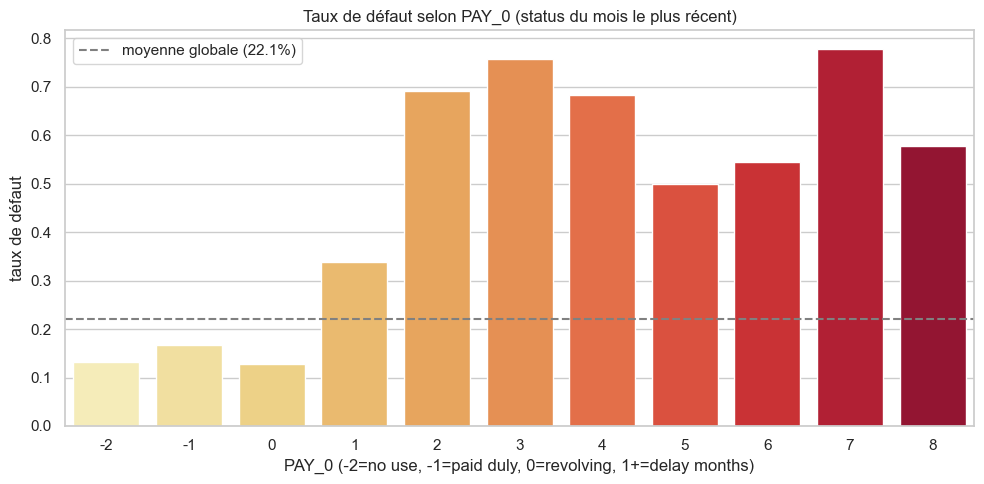

In [31]:
plt.figure(figsize=(10, 5))
rate = df.groupby('PAY_0')[TARGET].mean()
sns.barplot(x=rate.index.astype(str), y=rate.values, palette='YlOrRd')
plt.axhline(df[TARGET].mean(), color='gray', ls='--',
            label=f'moyenne globale ({df[TARGET].mean():.1%})')
plt.title('Taux de défaut selon PAY_0 (status du mois le plus récent)')
plt.ylabel('taux de défaut')
plt.xlabel('PAY_0 (-2=no use, -1=paid duly, 0=revolving, 1+=delay months)')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '06b_default_by_pay0.png', dpi=120, bbox_inches='tight')
plt.show()

## 7️⃣ Analyse multivariée

**Objectif** : repérer corrélations entre variables (multicolinéarité)
et les plus liées à la cible.

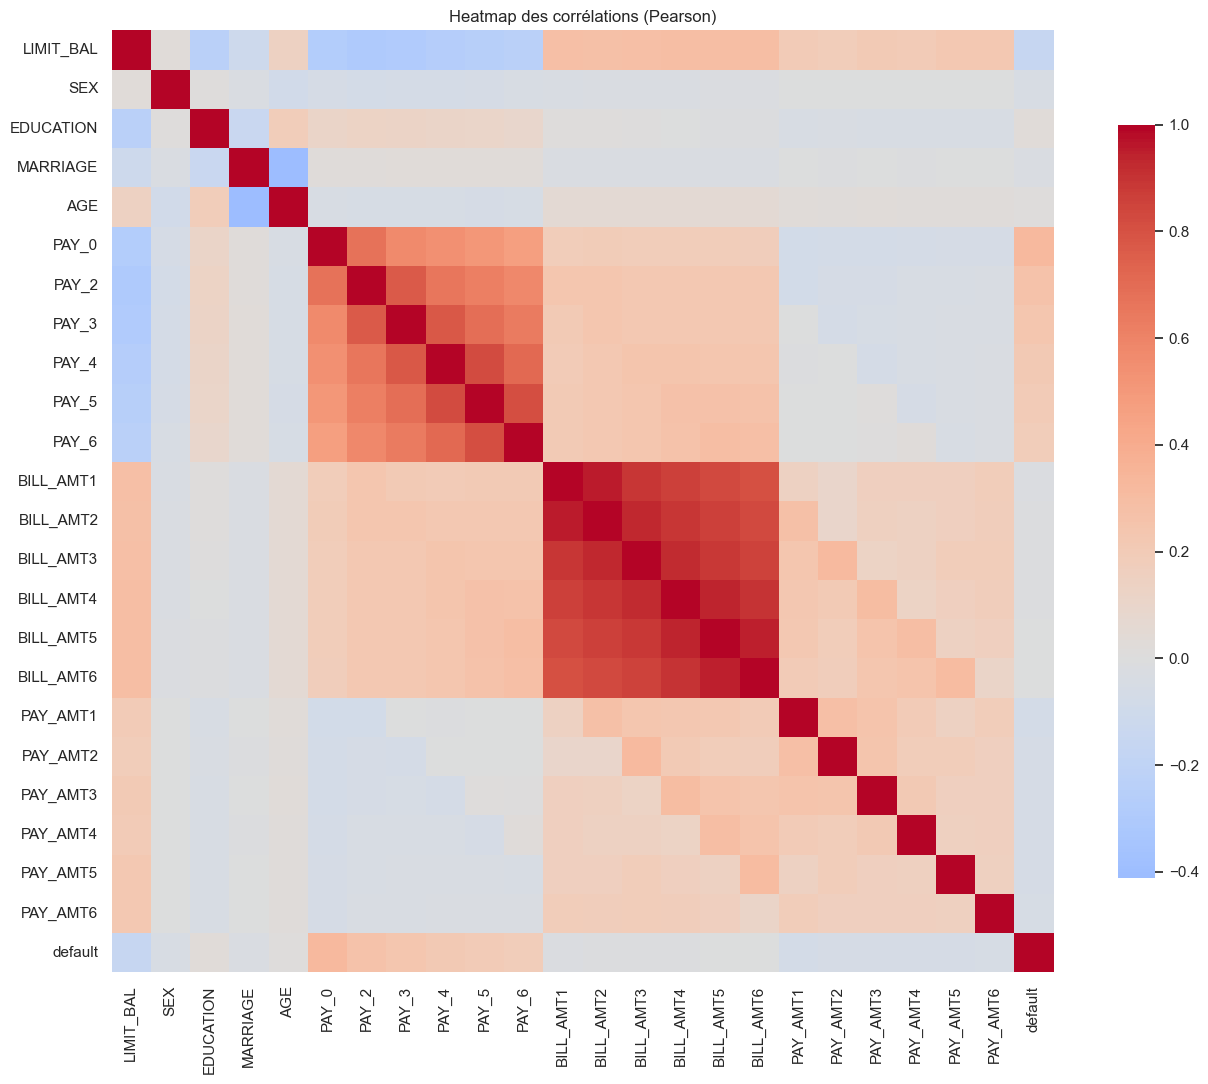

In [32]:
# Matrice de corrélation Pearson
corr = df.corr(method='pearson')
plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Heatmap des corrélations (Pearson)')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_corr_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

In [33]:
# Top corrélations avec la cible
corr_target = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print('Top 15 variables les plus corrélées (en valeur absolue) avec default :')
print(corr_target.head(15).round(3))

Top 15 variables les plus corrélées (en valeur absolue) avec default :
PAY_0        0.325
PAY_2        0.264
PAY_3        0.235
PAY_4        0.217
PAY_5        0.204
PAY_6        0.187
LIMIT_BAL    0.154
PAY_AMT1     0.073
PAY_AMT2     0.059
PAY_AMT4     0.057
PAY_AMT3     0.056
PAY_AMT5     0.055
PAY_AMT6     0.053
SEX          0.040
EDUCATION    0.034
Name: default, dtype: float64


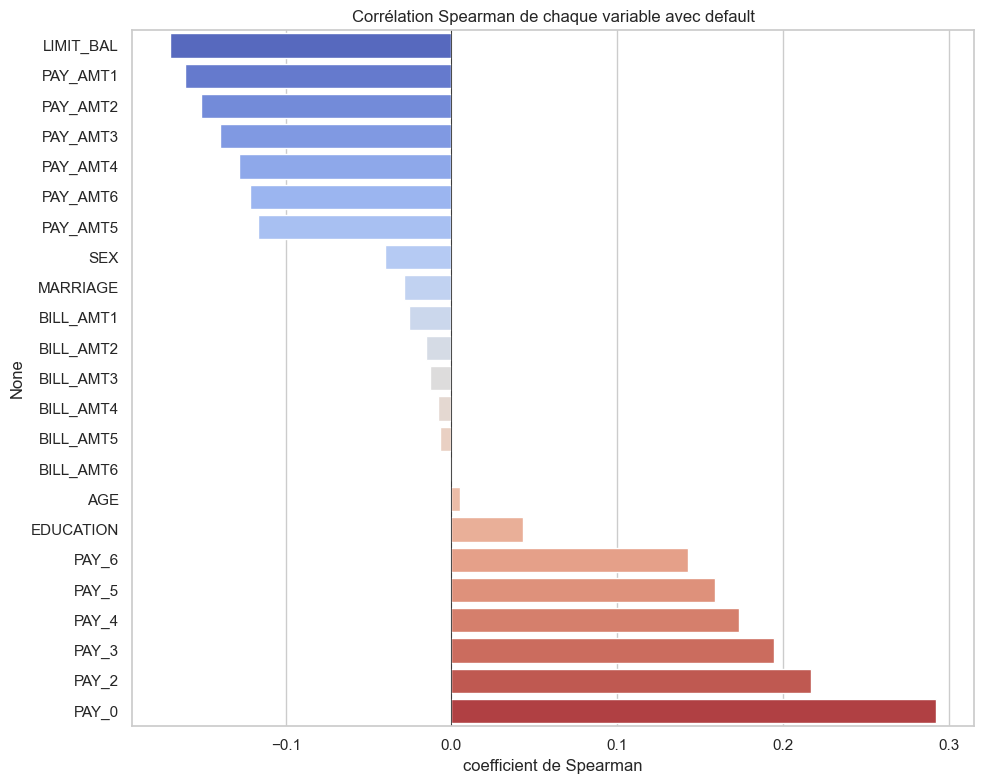

In [34]:
# Corrélation Spearman (basée sur les rangs, plus robuste aux outliers)
corr_s = df.corr(method='spearman')
corr_s_target = corr_s[TARGET].drop(TARGET).sort_values()
plt.figure(figsize=(10, 8))
sns.barplot(x=corr_s_target.values, y=corr_s_target.index,
            palette='coolwarm')
plt.axvline(0, color='black', lw=0.5)
plt.title('Corrélation Spearman de chaque variable avec default')
plt.xlabel('coefficient de Spearman')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_corr_spearman_target.png', dpi=120, bbox_inches='tight')
plt.show()

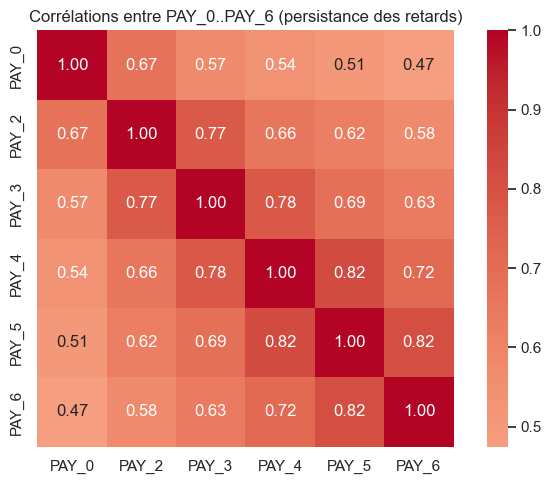

In [35]:
# Corrélations entre PAY_* (devraient être fortement positives :
# les retards sont persistants dans le temps)
plt.figure(figsize=(7, 5))
sns.heatmap(df[PAY_COLS].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True)
plt.title('Corrélations entre PAY_0..PAY_6 (persistance des retards)')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_corr_pay_block.png', dpi=120, bbox_inches='tight')
plt.show()

## 8️⃣ Détection des outliers

**Objectif** : identifier les valeurs extrêmes susceptibles de perturber
les modèles linéaires. Nous gardons les outliers (XGBoost et RandomForest
y sont robustes), mais on les signale pour le standardisation côté
LogisticRegression.

In [36]:
# Méthode IQR — % d'outliers par variable numérique clé
num_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']
outliers_pct = {}
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[col] < low) | (df[col] > high)
    outliers_pct[col] = mask.mean() * 100

pd.Series(outliers_pct).round(2).to_frame('% outliers IQR')

,% outliers IQR
LIMIT_BAL,0.56
AGE,0.91
BILL_AMT1,8.00
PAY_AMT1,9.15


In [37]:
# Z-score : % de points |z| > 3
zscore_pct = {}
for col in num_cols:
    z = np.abs((df[col] - df[col].mean()) / df[col].std())
    zscore_pct[col] = (z > 3).mean() * 100
pd.Series(zscore_pct).round(2).to_frame('% outliers Z>3')

,% outliers Z>3
LIMIT_BAL,0.43
AGE,0.47
BILL_AMT1,2.29
PAY_AMT1,1.30


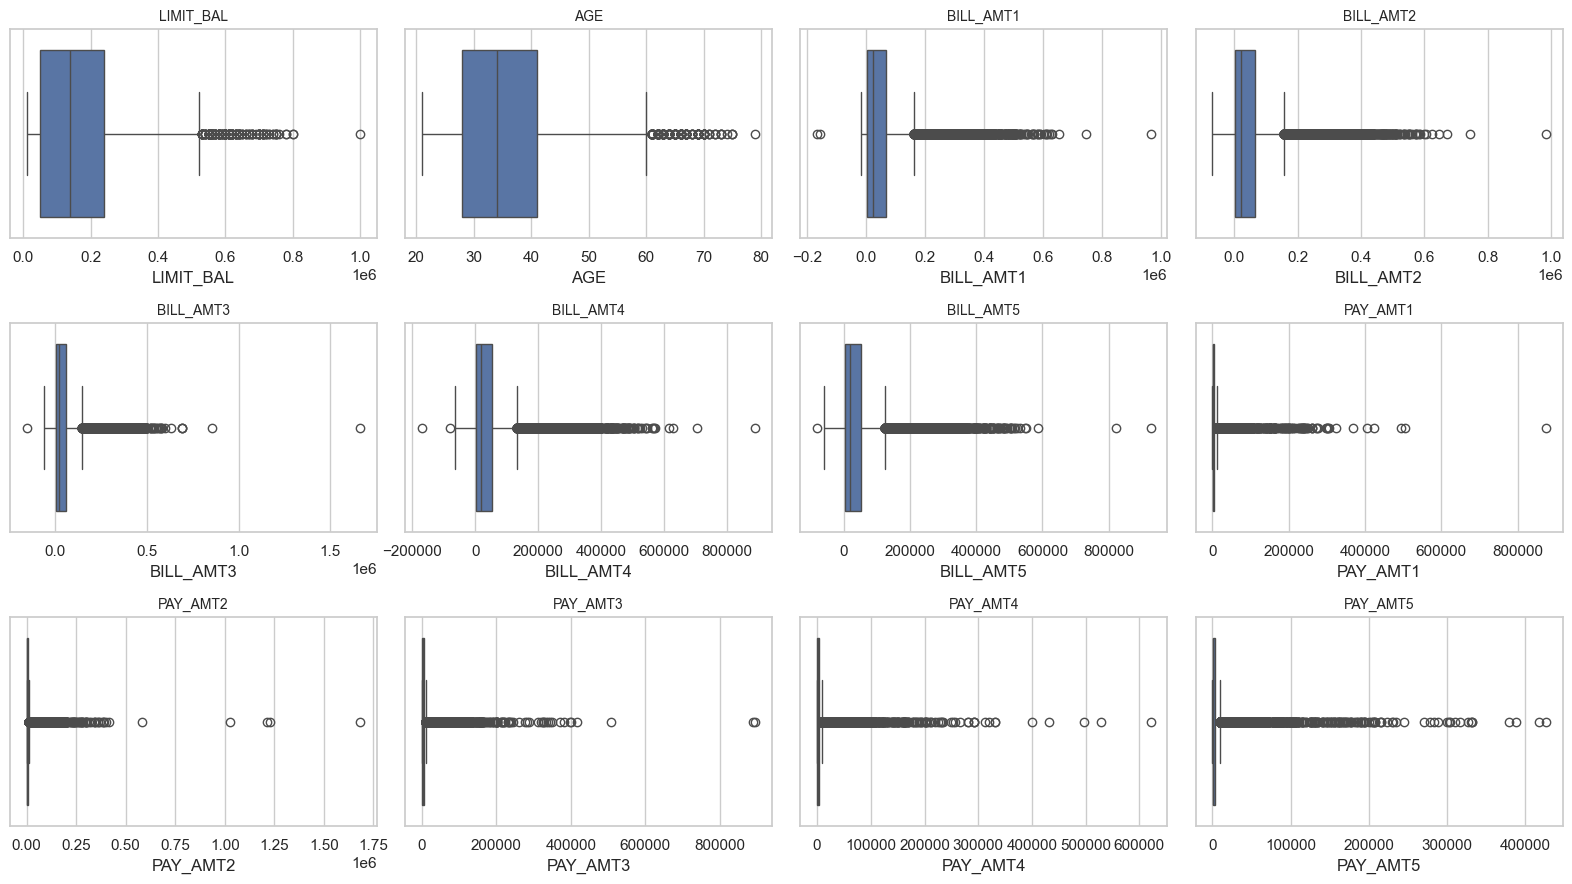

In [38]:
# Grille de boxplots pour visualisation rapide
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
cols_box = (['LIMIT_BAL', 'AGE'] + BILL_COLS[:5] + PAY_AMT_COLS[:5])
for ax, col in zip(axes.ravel(), cols_box):
    sns.boxplot(x=df[col], ax=ax, color='#4C72B0')
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / '08_boxplots_grid.png', dpi=120, bbox_inches='tight')
plt.show()

## 9️⃣ Analyses temporelles (6 mois)

**Objectif** : exploiter la dimension temporelle (avril → septembre 2005).
Indices : tendance des factures, persistance des retards, % de clients
en retard chaque mois.

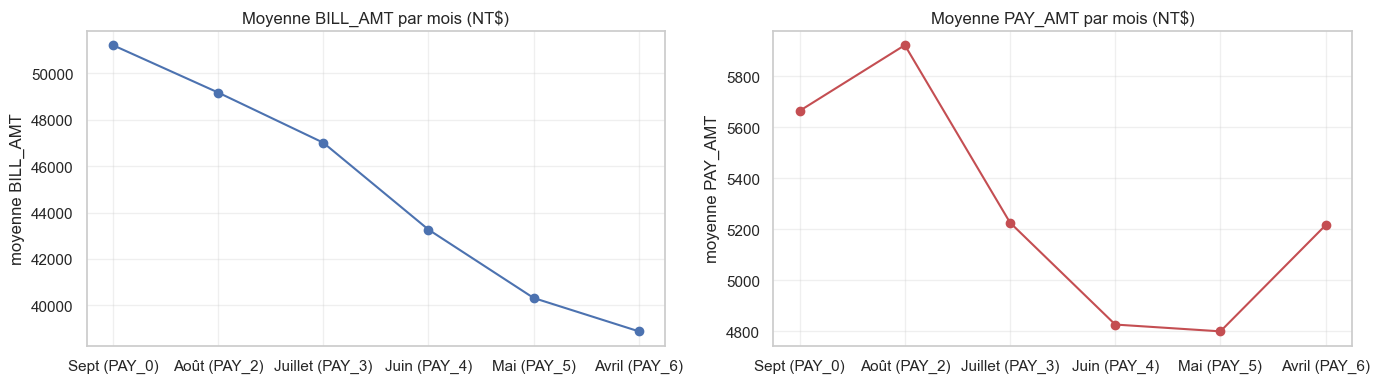

In [39]:
# Mapping mois → label lisible (PAY_0 = septembre, PAY_6 = avril)
months = ['Sept (PAY_0)', 'Août (PAY_2)', 'Juillet (PAY_3)',
          'Juin (PAY_4)', 'Mai (PAY_5)', 'Avril (PAY_6)']

# Évolution de la moyenne BILL_AMT et PAY_AMT
bill_mean = df[BILL_COLS].mean()
pay_mean = df[PAY_AMT_COLS].mean()
bill_mean.index = months
pay_mean.index = months

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
bill_mean.plot(kind='line', marker='o', ax=axes[0], color='#4C72B0')
axes[0].set_title('Moyenne BILL_AMT par mois (NT$)')
axes[0].set_ylabel('moyenne BILL_AMT')
axes[0].grid(alpha=0.3)

pay_mean.plot(kind='line', marker='o', ax=axes[1], color='#C44E52')
axes[1].set_title('Moyenne PAY_AMT par mois (NT$)')
axes[1].set_ylabel('moyenne PAY_AMT')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '09_temporal_means.png', dpi=120, bbox_inches='tight')
plt.show()

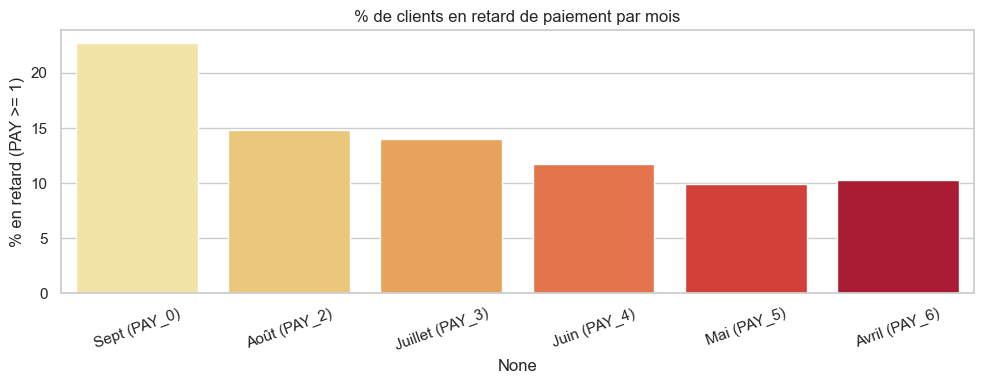

In [40]:
# % de clients en retard (PAY_X >= 1) chaque mois
delay_pct = (df[PAY_COLS] >= 1).mean() * 100
delay_pct.index = months
plt.figure(figsize=(10, 4))
sns.barplot(x=delay_pct.index, y=delay_pct.values, palette='YlOrRd')
plt.title('% de clients en retard de paiement par mois')
plt.ylabel('% en retard (PAY >= 1)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / '09_delay_pct_per_month.png', dpi=120, bbox_inches='tight')
plt.show()

## 🛠️ Feature engineering

Les 12 features dérivées créées dans `engineer_features()` (voir
`src/scoring/data.py`).

In [41]:
df_full = engineer_features(df)
new_cols = [c for c in df_full.columns if c not in df.columns]
print(f'{len(new_cols)} features ajoutées :')
for c in new_cols:
    print(f'  - {c}')

df_full[new_cols].describe().T

12 features ajoutées :
  - PAY_DELAY_COUNT
  - MAX_DELAY
  - MEAN_PAY_STATUS
  - HAS_EVER_DELAYED
  - UTIL_RATIO_1
  - MEAN_UTIL
  - MAX_UTIL
  - TOTAL_PAID
  - TOTAL_BILLED
  - PAY_TO_BILL_RATIO
  - BILL_TREND
  - PAY_TREND


,count,mean,std,min,25%,50%,75%,max
PAY_DELAY_COUNT,30000.0,0.834200,1.554303,0.000000,0.000000,0.000000,1.000000,6.000000e+00
MAX_DELAY,30000.0,0.438733,1.345154,-2.000000,0.000000,0.000000,2.000000,8.000000e+00
MEAN_PAY_STATUS,30000.0,-0.182439,0.982176,-2.000000,-0.833333,0.000000,0.000000,6.000000e+00
HAS_EVER_DELAYED,30000.0,0.335633,0.472219,0.000000,0.000000,0.000000,1.000000,1.000000e+00
UTIL_RATIO_1,30000.0,0.423771,0.411462,-0.619892,0.022032,0.313994,0.829843,6.455300e+00
MEAN_UTIL,30000.0,0.373048,0.351890,-0.232590,0.029997,0.284834,0.687929,5.364308e+00
MAX_UTIL,30000.0,0.494965,0.433046,-0.100000,0.070636,0.430702,0.923246,1.068858e+01
TOTAL_PAID,30000.0,31651.392567,60827.677939,0.000000,6679.750000,14383.000000,33503.500000,3.764066e+06
TOTAL_BILLED,30000.0,269861.671200,379564.331162,-336259.000000,28688.000000,126311.000000,342626.500000,5.263883e+06
PAY_TO_BILL_RATIO,30000.0,0.469158,5.506705,0.000000,0.040952,0.084932,0.586922,7.970000e+02


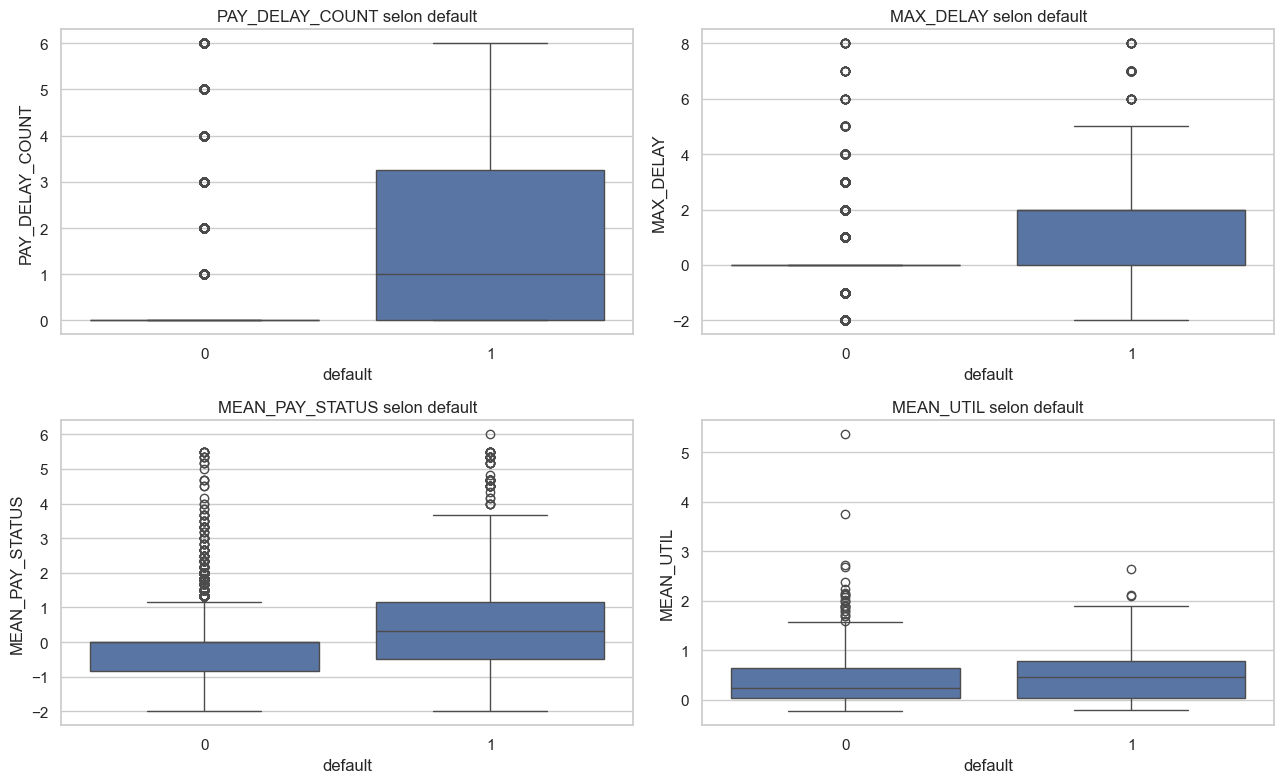

In [42]:
# Distribution des nouvelles features les plus parlantes par classe
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.ravel(),
                   ['PAY_DELAY_COUNT', 'MAX_DELAY',
                    'MEAN_PAY_STATUS', 'MEAN_UTIL']):
    sns.boxplot(x=TARGET, y=col, data=df_full, ax=ax)
    ax.set_title(f'{col} selon default')
plt.tight_layout()
plt.savefig(FIG_DIR / '10_engineered_features.png', dpi=120, bbox_inches='tight')
plt.show()

In [43]:
# Top corrélations des features engineered avec la cible
corr_full = df_full.corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print('Top 15 variables (cleaned + engineered) corrélées avec default :')
print(corr_full.head(15).round(3))

Top 15 variables (cleaned + engineered) corrélées avec default :
PAY_DELAY_COUNT     0.398
HAS_EVER_DELAYED    0.353
MAX_DELAY           0.331
PAY_0               0.325
MEAN_PAY_STATUS     0.282
PAY_2               0.264
PAY_3               0.235
PAY_4               0.217
PAY_5               0.204
PAY_6               0.187
LIMIT_BAL           0.154
MEAN_UTIL           0.115
TOTAL_PAID          0.102
UTIL_RATIO_1        0.086
MAX_UTIL            0.082
Name: default, dtype: float64


In [44]:
# Sauvegarde du dataset processed
out = ROOT / 'data' / 'processed' / 'credit_clean.parquet'
out.parent.mkdir(parents=True, exist_ok=True)
df_full.to_parquet(out, index=False)
print(f'Saved → {out.relative_to(ROOT)}')
print(f'Shape : {df_full.shape}')

Saved → data/processed/credit_clean.parquet
Shape : (30000, 36)


## 📌 Synthèse des findings

| # | Finding |
|---|---------|
| 1 | Dataset **propre** : aucune valeur manquante, mais quelques codes non documentés sur EDUCATION et MARRIAGE → traités |
| 2 | Cible **déséquilibrée** : 22% de défauts → SMOTE ou class_weight indispensable |
| 3 | Les variables **`PAY_*`** (historique de paiement) sont **de très loin les plus prédictives** |
| 4 | `LIMIT_BAL` et `AGE` montrent des différences statistiquement significatives entre classes (Mann-Whitney p < 1e-50) |
| 5 | Les tests **Chi²** confirment que `SEX`, `EDUCATION`, `MARRIAGE` sont liées à la cible (p < 0.001) |
| 6 | Forte **corrélation entre BILL_AMT successifs** (~0.95) → multicolinéarité → préférer des features agrégées |
| 7 | Le dataset est **stable dans le temps** : pas de tendance majeure sur 6 mois (utile pour la baseline drift) |
| 8 | **12 features dérivées** créées : MEAN_PAY_STATUS, PAY_DELAY_COUNT, MEAN_UTIL, etc. — capturent le comportement global |
| 9 | Dataset processed sauvegardé dans `data/processed/credit_clean.parquet` (36 colonnes, 30 000 lignes) |

Prochaine étape : définir la **fonction de score métier** (Étape 3 de l'examen).